# CHORD UV Coverage & Dirty Beam Analysis

Evaluate how different antenna configurations (compact core, outrigger stations A and B)
affect UV coverage and angular resolution at 900 MHz.

In [11]:
from astropy.coordinates import EarthLocation
import importlib
import sys
importlib.invalidate_caches()
sys.modules.pop("uv_utils", None)
from uv_utils import (
    utm_txt_to_earthlocations,
    combine_locations,
    setup_uvdata,
    plot_antenna_positions,
    plot_uv_coverage,
    compute_dirty_beam,
    adaptive_briggs_sweep,
    plot_briggs_values,
    _apply_weighting
)

drao_loc = EarthLocation.of_site("DRAO")
FREQ_HZ = 900e6

## Load Antenna Layouts

In [4]:
compact    = utm_txt_to_earthlocations("../../geo_data/layouts/shifted_SW_trimmed2.txt")
location_A = utm_txt_to_earthlocations("../../geo_data/layouts/location_A.txt")
location_A2 = utm_txt_to_earthlocations("../../geo_data/layouts/location_A_2.txt")
location_B = utm_txt_to_earthlocations("../../geo_data/layouts/location_B.txt")
location_C = utm_txt_to_earthlocations("../../geo_data/layouts/location_C.txt")
location_D = utm_txt_to_earthlocations("../../geo_data/layouts/location_D.txt")
location_E = utm_txt_to_earthlocations("../../geo_data/layouts/location_E.txt")
location_F = utm_txt_to_earthlocations("../../geo_data/layouts/location_F.txt")
location_G = utm_txt_to_earthlocations("../../geo_data/layouts/location_G.txt")

compact_A  = combine_locations(compact, location_A)
compact_B  = combine_locations(compact, location_B)
compact_AB = combine_locations(compact, location_A, location_B)
compact_A2 = combine_locations(compact, location_A2)
compact_C  = combine_locations(compact, location_C)
compact_D  = combine_locations(compact, location_D)
compact_E  = combine_locations(compact, location_E)
compact_F  = combine_locations(compact, location_F)
compact_G  = combine_locations(compact, location_G)

Loaded 512 antennas from '../../geo_data/layouts/shifted_SW_trimmed2.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_A.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_A_2.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_B.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_C.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_D.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_E.txt'
Loaded 16 antennas from '../../geo_data/layouts/location_F.txt'
Loaded 8 antennas from '../../geo_data/layouts/location_G.txt'


## UV Coverage

In [17]:
uvd_compact    = setup_uvdata(compact,    drao_loc, freq_hz=FREQ_HZ)
# uvd_compact_A  = setup_uvdata(compact_A,  drao_loc, freq_hz=FREQ_HZ)
# uvd_compact_B  = setup_uvdata(compact_B,  drao_loc, freq_hz=FREQ_HZ)
# uvd_compact_AB = setup_uvdata(compact_AB, drao_loc, freq_hz=FREQ_HZ)


Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


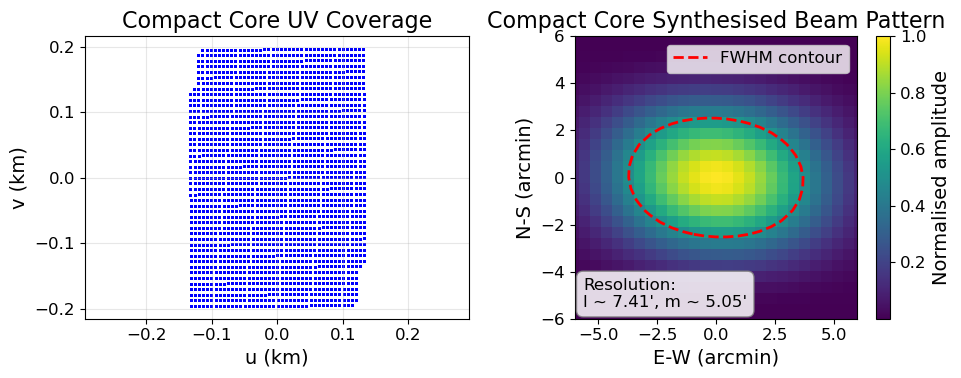

In [21]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})
beam, l_arcmin, m_arcmin, eff_l_arcmin, eff_m_arcmin, relative_noise = compute_dirty_beam(uvd_compact, title=f"Compact Core",
    npix=256, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="natural", zoom_extent=10, plot_beam=False)

zoom_extent = 6
extent = (
    float(l_arcmin[0]),
    float(l_arcmin[-1]),
    float(m_arcmin[0]),
    float(m_arcmin[-1]),
)

u_km = uvd_compact.uvw_array[:, 0] / 1e3
v_km = uvd_compact.uvw_array[:, 1] / 1e3

fig, (ax_uv, ax_beam) = plt.subplots(1, 2, figsize=(10, 4))

# Beam subplot
im = ax_beam.imshow(beam, origin="lower", extent=extent, cmap="viridis")
ax_beam.contour(
    beam,
    levels=[0.5],
    colors="red",
    linewidths=2.0,
    linestyles="--",
    extent=extent,
)
ax_beam.plot([], [], color="red", linestyle="--", linewidth=2, label="FWHM contour")
ax_beam.legend(loc="upper right")
fig.colorbar(im, ax=ax_beam, label="Normalised amplitude")
info = (
    f"Resolution:\nl ~ {eff_l_arcmin:.2f}', m ~ {eff_m_arcmin:.2f}'"
)
ax_beam.text(0.03, 0.03, info, transform=ax_beam.transAxes, ha="left", va="bottom",
        fontsize=12, bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                                alpha=0.85, edgecolor="gray"))

ax_beam.set_xlim(-zoom_extent, zoom_extent)
ax_beam.set_ylim(-zoom_extent, zoom_extent)
ax_beam.set_xlabel("E-W (arcmin)")
ax_beam.set_ylabel("N-S (arcmin)")
ax_beam.set_title("Compact Core Synthesised Beam Pattern")

# UV coverage subplot
ax_uv.scatter(u_km, v_km, s=0.2, alpha=0.25, color="blue")
ax_uv.scatter(-u_km, -v_km, s=0.2, alpha=0.25, color="blue")
ax_uv.set_xlabel("u (km)")
ax_uv.set_ylabel("v (km)")
ax_uv.set_title("Compact Core UV Coverage")
ax_uv.axis("equal")
ax_uv.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../thesis/plots/ext_chord/uv_coverage_and_beam.png", dpi=300)
plt.show()

## Plot of Core plus A

In [5]:
uvd_compact_A = setup_uvdata(compact_A, drao_loc, freq_hz=FREQ_HZ)

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


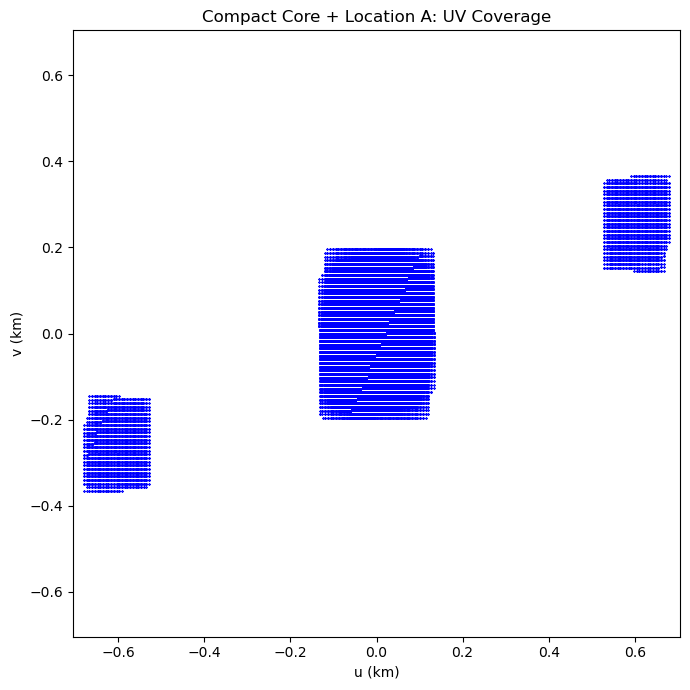

In [6]:
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt

u_km = uvd_compact_A.uvw_array[:, 0]/1e3
v_km = uvd_compact_A.uvw_array[:, 1]/1e3

fig, ax = plt.subplots(figsize=(7, 7))

u_km_sampled = u_km[::50]
v_km_sampled = v_km[::50]
ax.scatter(u_km_sampled, v_km_sampled, s=0.05, color="blue", alpha=0.7)
ax.scatter(-u_km_sampled, -v_km_sampled, s=0.05, color="blue", alpha=0.7)

ax.set_xlabel("u (km)")
ax.set_ylabel("v (km)")
ax.set_title("Compact Core + Location A: UV Coverage")
ax.axis("equal")

plt.xlim(-0.7, 0.7)
plt.ylim(-0.7, 0.7)
plt.tight_layout()
plt.show()

Sampled 10 robust values in 8 bisections, total iterations: 8


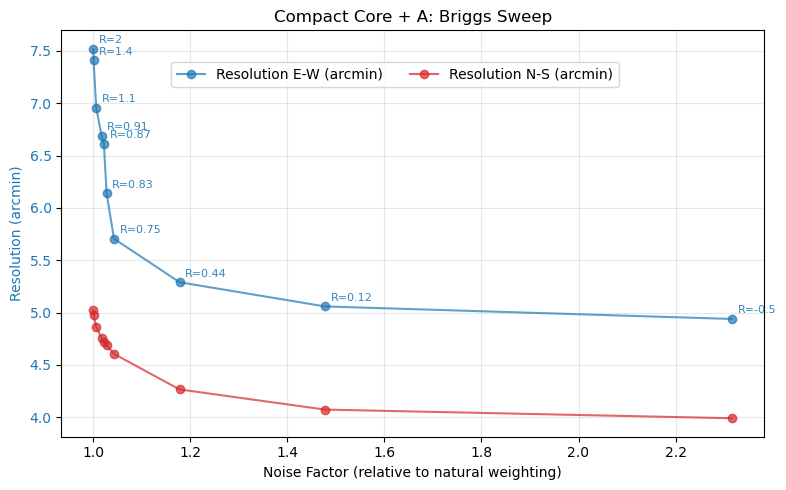

In [8]:
r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_A, tol=0.5, npix=256, image_extent_deg=1, r_hi=2, r_lo=-0.5
)

plot_briggs_values("Compact Core + A: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

In [18]:
FREQ_HZ

900000000.0

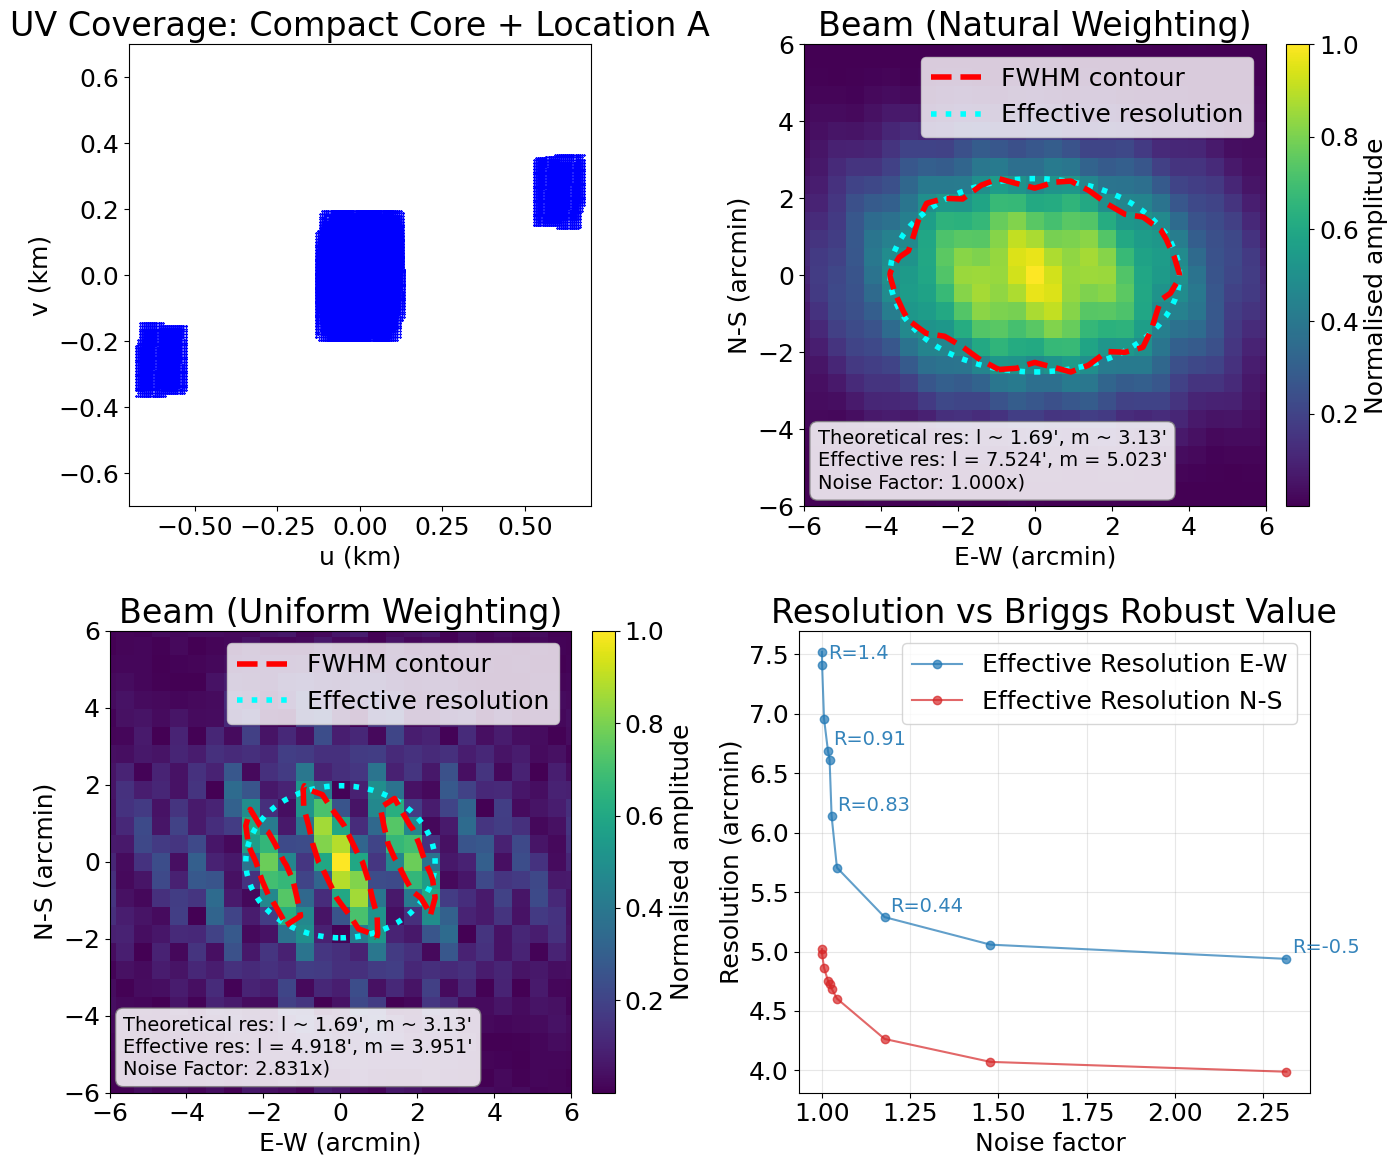

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# --- shared params (tweak freely) ---
NPIX = 256
IMAGE_EXTENT_DEG = 1
ZOOM_EXTENT = 6         # arcmin half-window for the beam panels
lambda_m = 3e8 / FREQ_HZ

def theoretical_res_arcmin(uvd):
    """Theoretical 1/u, 1/v resolution in arcmin (matches compute_dirty_beam)."""
    u_lam = np.concatenate([uvd.uvw_array[:, 0], -uvd.uvw_array[:, 0]]) / lambda_m
    v_lam = np.concatenate([uvd.uvw_array[:, 1], -uvd.uvw_array[:, 1]]) / lambda_m
    max_u, max_v = np.abs(u_lam).max(), np.abs(v_lam).max()
    theta_l = (1.0 / max_u) * (180 / np.pi * 60) if max_u > 0 else np.nan
    theta_m = (1.0 / max_v) * (180 / np.pi * 60) if max_v > 0 else np.nan
    return theta_l, theta_m

def plot_beam_panel(ax, uvd, weighting, title):
    beam, l_arcmin, m_arcmin, eff_l, eff_m, rel_noise = compute_dirty_beam(
        uvd, npix=NPIX, freq_hz=FREQ_HZ, image_extent_deg=IMAGE_EXTENT_DEG,
        weighting=weighting, plot_beam=False,
    )
    extent = (float(l_arcmin[0]), float(l_arcmin[-1]),
              float(m_arcmin[0]), float(m_arcmin[-1]))
    theta_l, theta_m = theoretical_res_arcmin(uvd)

    im = ax.imshow(beam, origin="lower", extent=extent, cmap="viridis")
    fig.colorbar(im, ax=ax, label="Normalised amplitude", fraction=0.046, pad=0.04)

    # Standard FWHM: half-max contour of the dirty beam
    ax.contour(beam, levels=[0.5], colors="red", linewidths=4.0,
               linestyles="--", extent=extent)
    ax.plot([], [], color="red", linestyle="--", linewidth=4, label="FWHM contour")

    # Effective FWHM: ellipse from the fitted-Gaussian FWHM (eff_l, eff_m)
    ax.add_patch(Ellipse((0, 0), width=eff_l, height=eff_m,
                         edgecolor="cyan", facecolor="none",
                         linewidth=4.0, linestyle=":"))
    ax.plot([], [], color="cyan", linestyle=":", linewidth=4, label="Effective resolution")
    ax.legend(loc="upper right")

    ax.set_xlim(-ZOOM_EXTENT, ZOOM_EXTENT)
    ax.set_ylim(-ZOOM_EXTENT, ZOOM_EXTENT)
    ax.set_xlabel("E-W (arcmin)")
    ax.set_ylabel("N-S (arcmin)")
    ax.set_title(title)

    info = (
        f"Theoretical res: l ~ {theta_l:.2f}', m ~ {theta_m:.2f}'\n"
        f"Effective res: l = {eff_l:.3f}', m = {eff_m:.3f}'\n"
        f"Noise Factor: {rel_noise:.3f}x)"
    )
    ax.text(0.03, 0.03, info, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=14, bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                                  alpha=0.85, edgecolor="gray"))

# ============================ Figure ============================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 26,
})
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax_uv, ax_nat = axes[0]
ax_uni, ax_briggs = axes[1]

# Top-left: UV coverage
u_km = uvd_compact_A.uvw_array[:, 0] / 1e3
v_km = uvd_compact_A.uvw_array[:, 1] / 1e3
ax_uv.scatter(u_km[::50], v_km[::50], s=0.05, color="blue", alpha=0.7)
ax_uv.scatter(-u_km[::50], -v_km[::50], s=0.05, color="blue", alpha=0.7)
ax_uv.set_xlabel("u (km)")
ax_uv.set_ylabel("v (km)")
ax_uv.set_title("UV Coverage: Compact Core + Location A")
ax_uv.set_aspect("equal")
ax_uv.set_xlim(-0.7, 0.7)
ax_uv.set_ylim(-0.7, 0.7)

# Top-right: natural weighting beam
plot_beam_panel(ax_nat, uvd_compact_A, "natural",
                "Beam (Natural Weighting)")

# Bottom-left: uniform weighting beam
plot_beam_panel(ax_uni, uvd_compact_A, "uniform",
                "Beam (Uniform Weighting)")

c_l, c_m = "tab:blue", "tab:red"
ax_briggs.plot(nf_arr, eff_l_arr, "o-", color=c_l, alpha=0.7, label="Effective Resolution E-W")
ax_briggs.plot(nf_arr, eff_m_arr, "o-", color=c_m, alpha=0.7, label="Effective Resolution N-S")

# Annotate each Briggs robust value
for nf_i, res_l_i, r_i in zip(nf_arr[::2], eff_l_arr[::2], r_arr[::2]):
    ax_briggs.annotate(f"R={r_i:.2g}", (nf_i, res_l_i),
                       textcoords="offset points", xytext=(4, 4),
                       fontsize=14, color=c_l, alpha=0.9)

ax_briggs.set_xlabel("Noise factor ")
ax_briggs.set_ylabel("Resolution (arcmin)")
ax_briggs.set_title("Resolution vs Briggs Robust Value")
ax_briggs.legend(loc="upper right")
ax_briggs.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../thesis/plots/ext_chord/loc_A_cov_and_beam.png", dpi=300)
plt.show()


## Dirty Beams — Compact Core + Location A

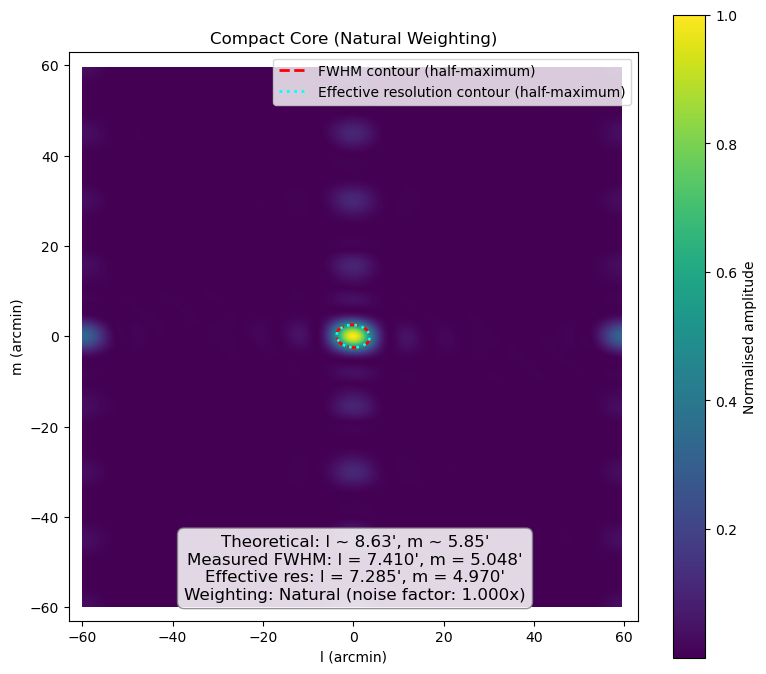

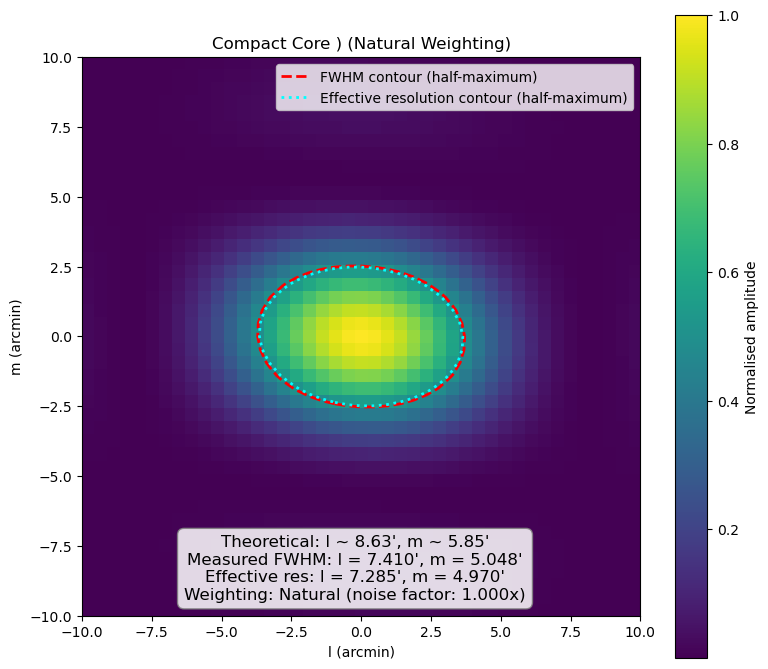

In [ ]:
for npix in [256]:
    compute_dirty_beam(uvd_compact, title=f"Compact Core",
                       npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="natural", zoom_extent=63)
    
    compute_dirty_beam(uvd_compact, title=f"Compact Core",
                       npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="natural", zoom_extent=10)


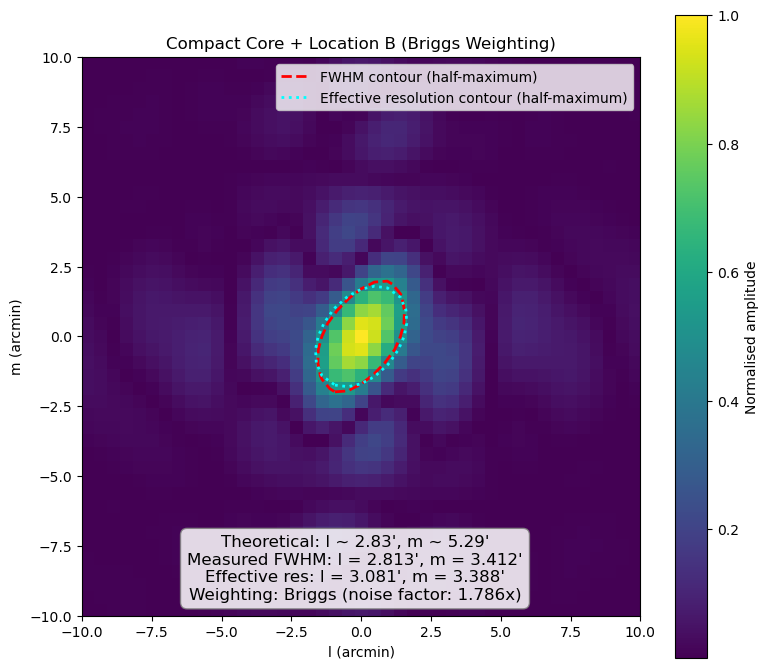

In [12]:
_ = compute_dirty_beam(uvd_compact_B, title=f"Compact Core + Location B",
                       npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, weighting="briggs", robust=0, zoom_extent=10)

## Noise factor, and effective resolution for Briggs weighting

Sampled 10 robust values in 8 bisections, total iterations: 8


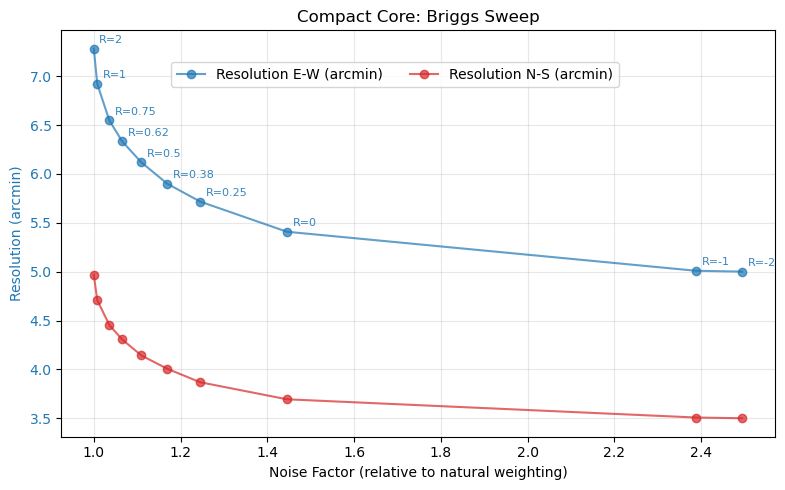

In [13]:
r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact, tol=0.4, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)


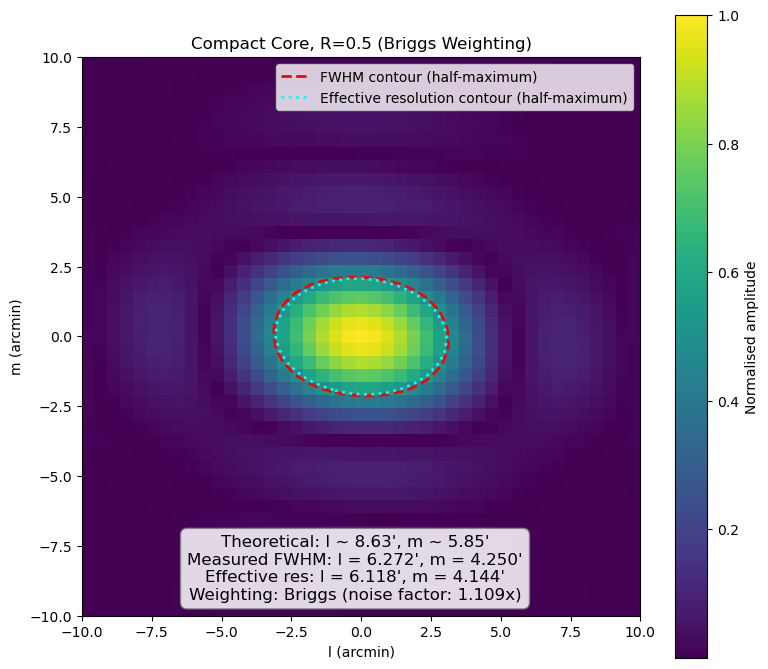

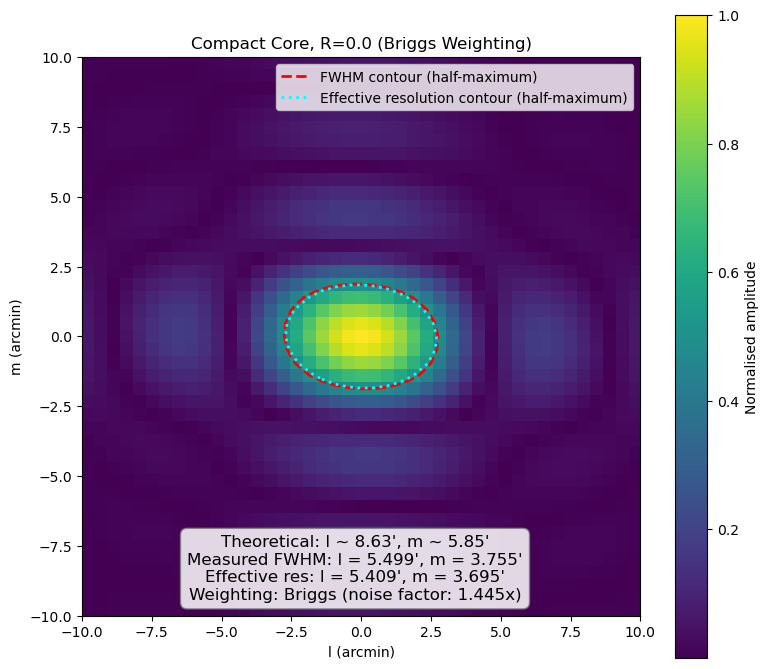

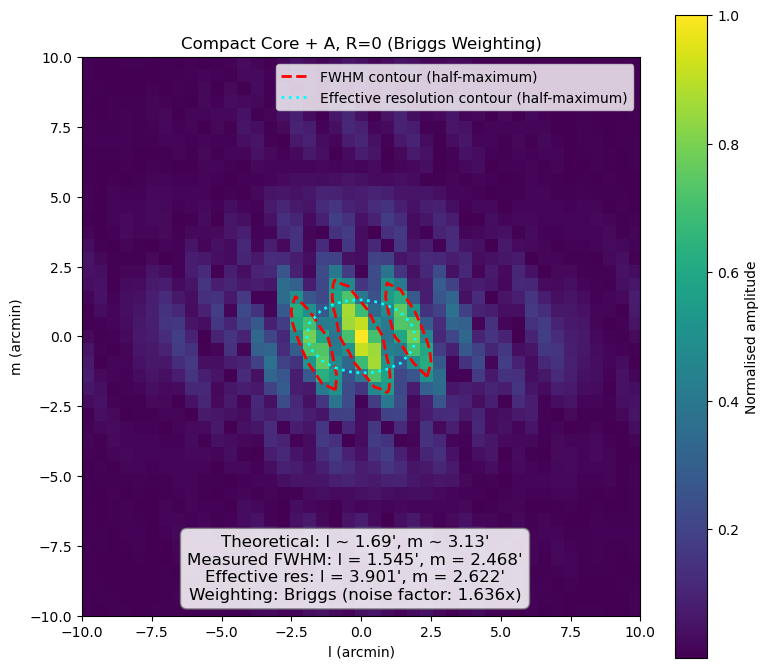

In [30]:
for R in [0.5, 0.0]:
    _ = compute_dirty_beam(uvd_compact, title=f"Compact Core, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)
_ = compute_dirty_beam(uvd_compact_A, title=f"Compact Core + A, R={0}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = 0, weighting="briggs", zoom_extent=10)

## Compact + A

Sampled 18 robust values in 16 bisections, total iterations: 16


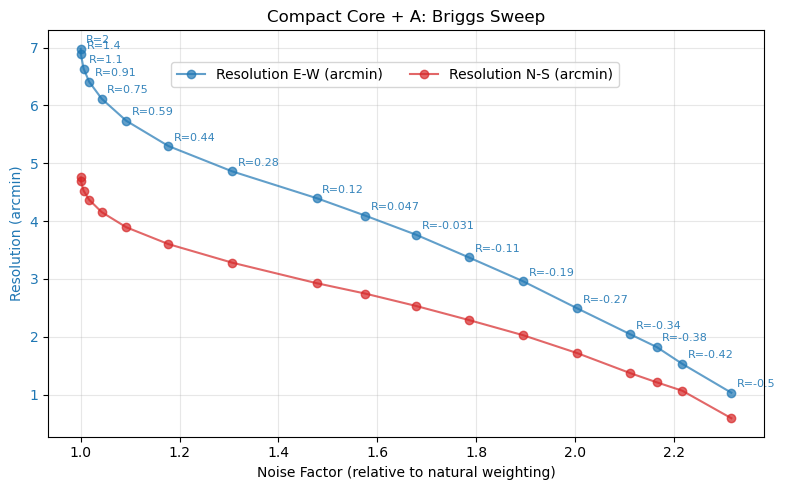

In [29]:
# uvd_compact_A  = setup_uvdata(compact_A,  drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_A, tol=0.5, npix=256, image_extent_deg=1, r_hi=2, r_lo=-0.5
)

plot_briggs_values("Compact Core + A: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

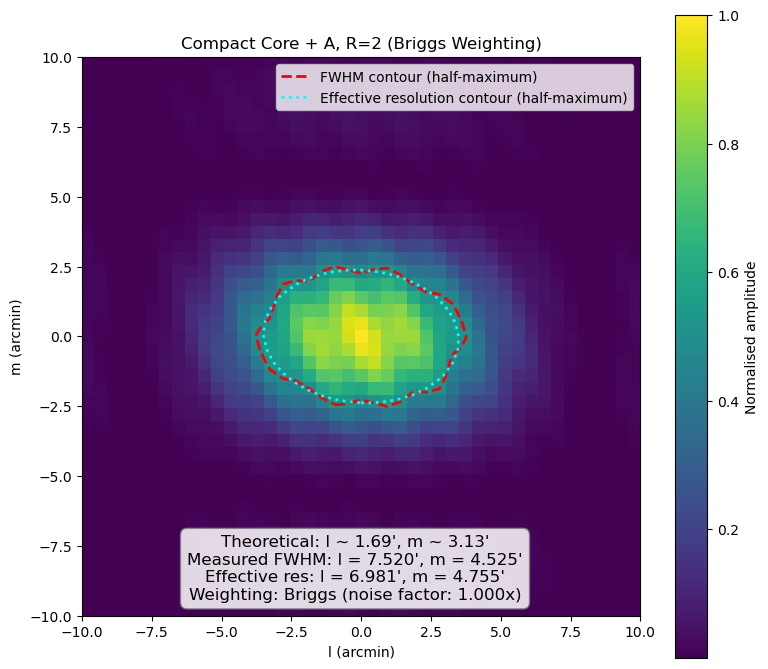

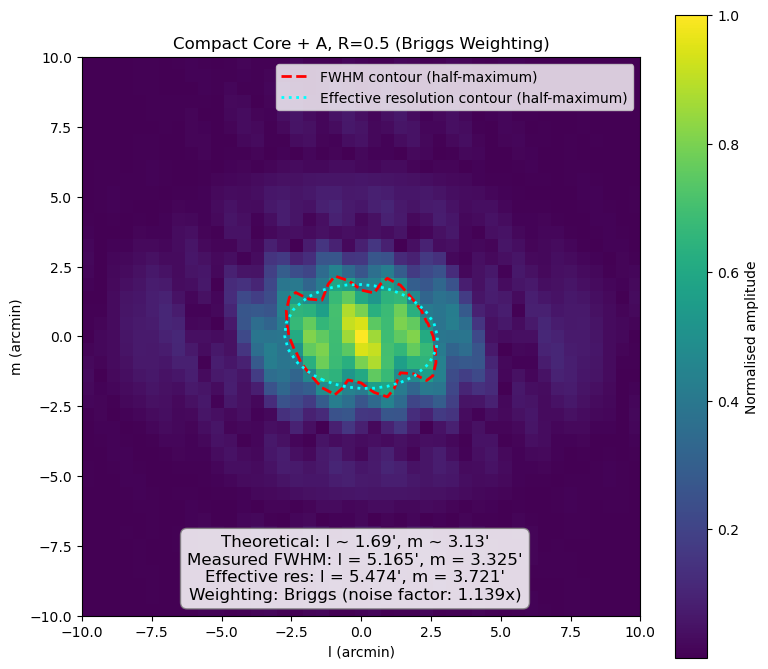

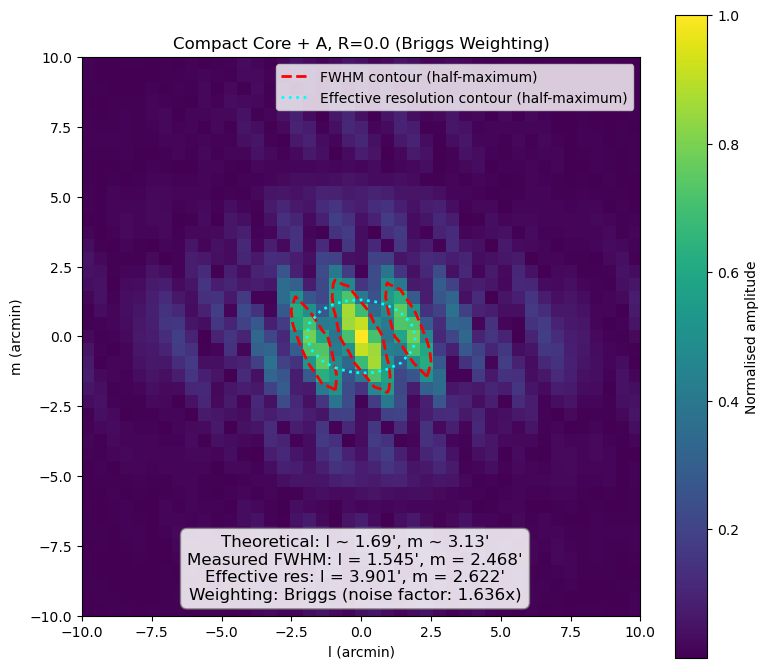

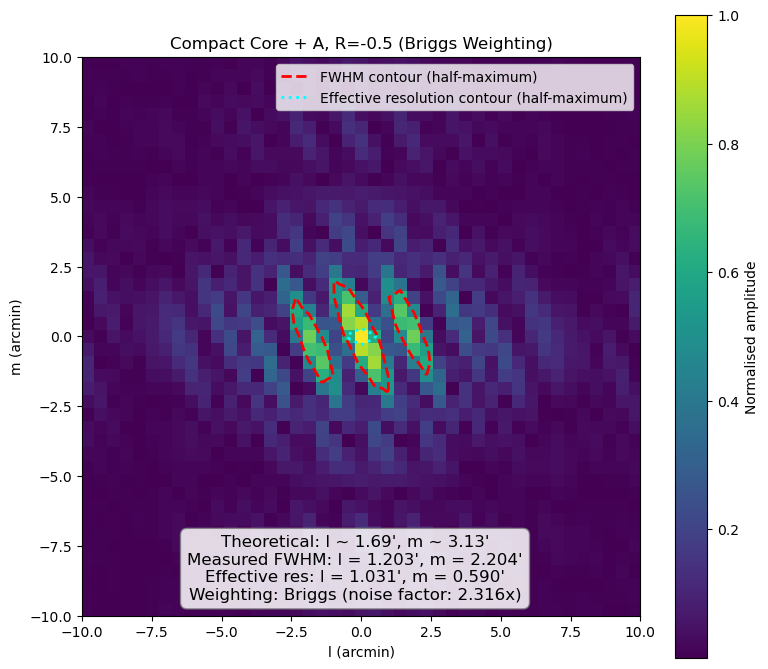

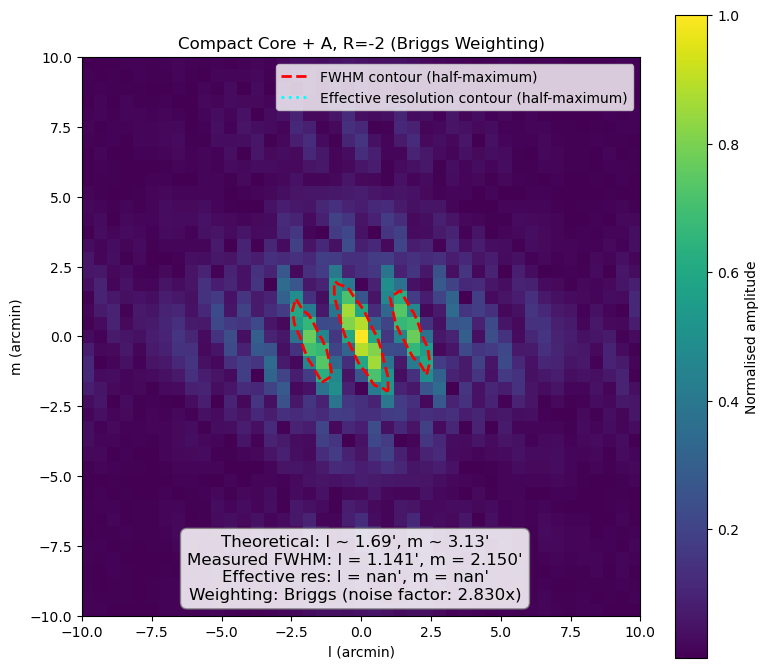

In [27]:
for R in [2, 0.5, 0.0, -0.5, -2]:
    _ = compute_dirty_beam(uvd_compact_A, title=f"Compact Core + A, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)


## Compact + B

Sampled 17 robust values in 15 bisections, total iterations: 15


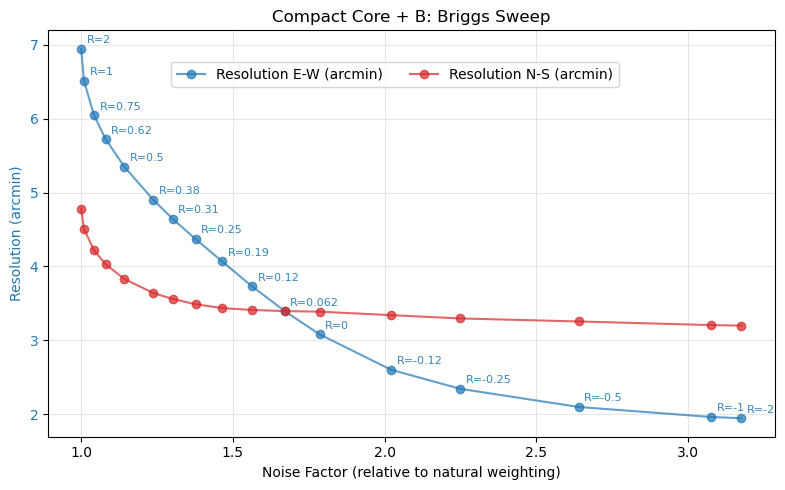

In [17]:
r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_B, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + B: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

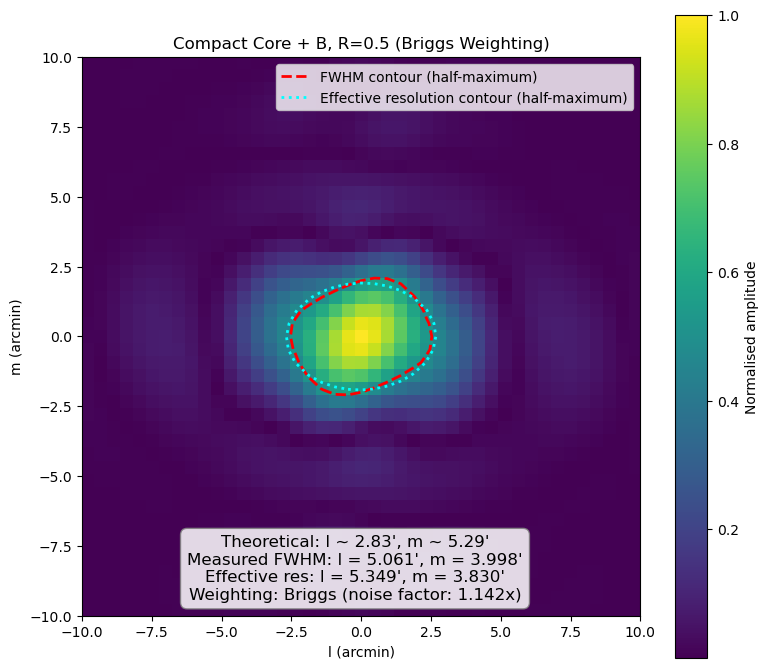

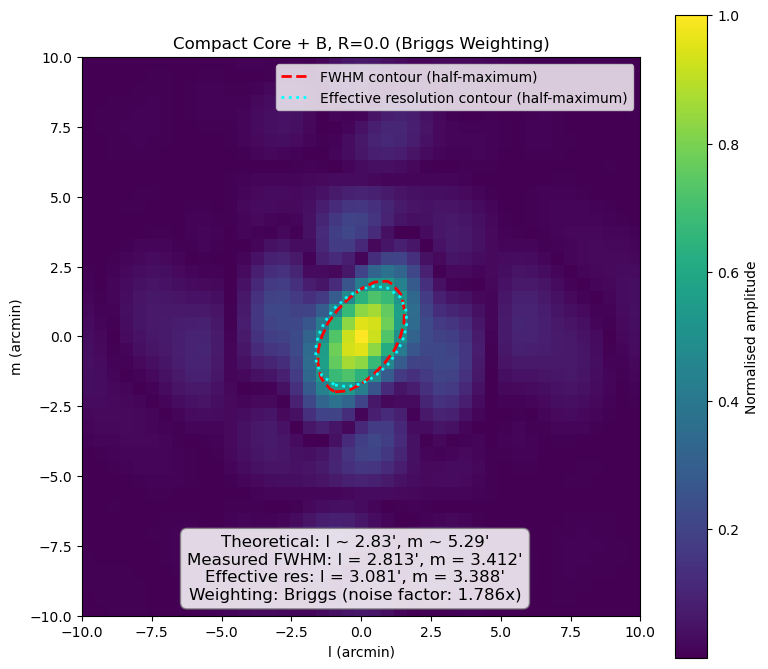

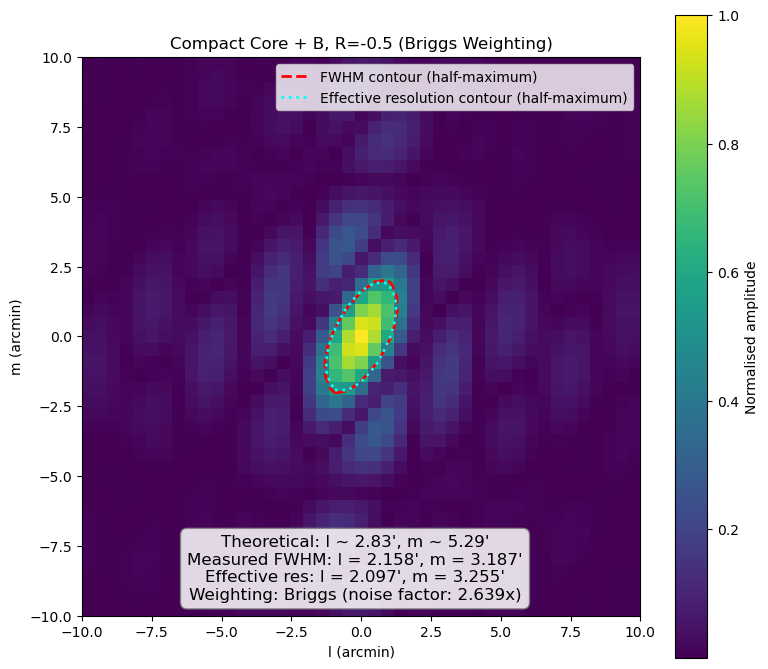

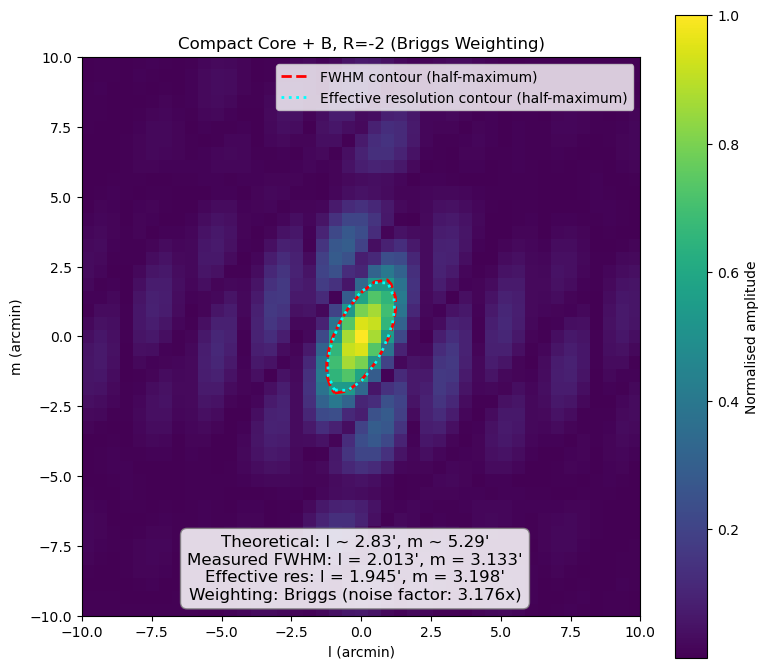

In [18]:
for R in [0.5, 0.0, -0.5, -2]:
    _ = compute_dirty_beam(uvd_compact_B, title=f"Compact Core + B, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + C

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 15 robust values in 13 bisections, total iterations: 13


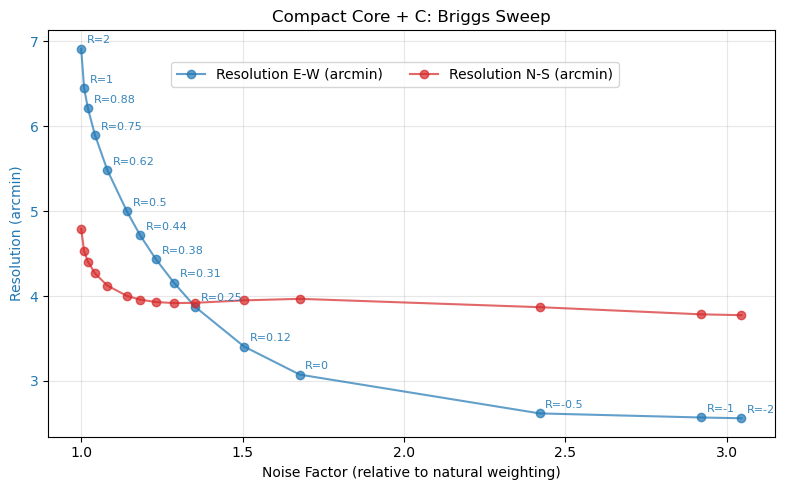

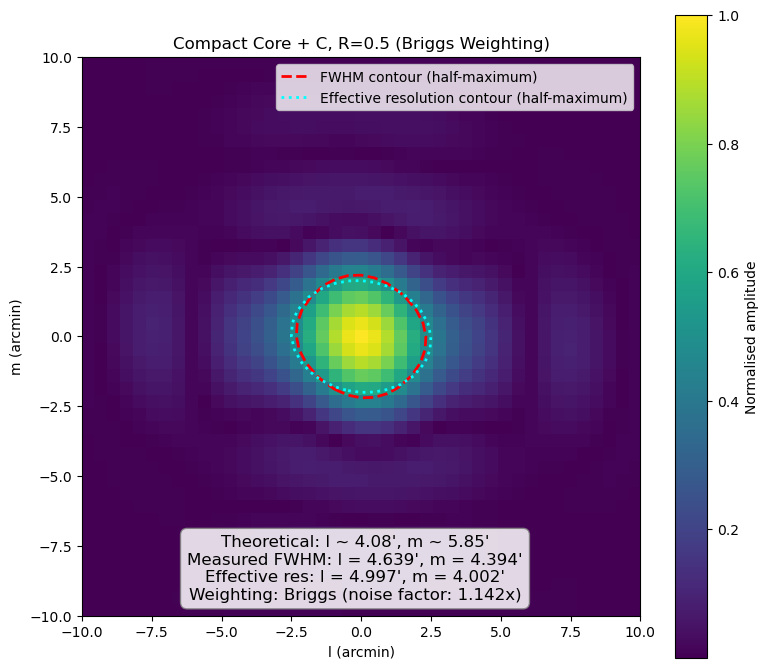

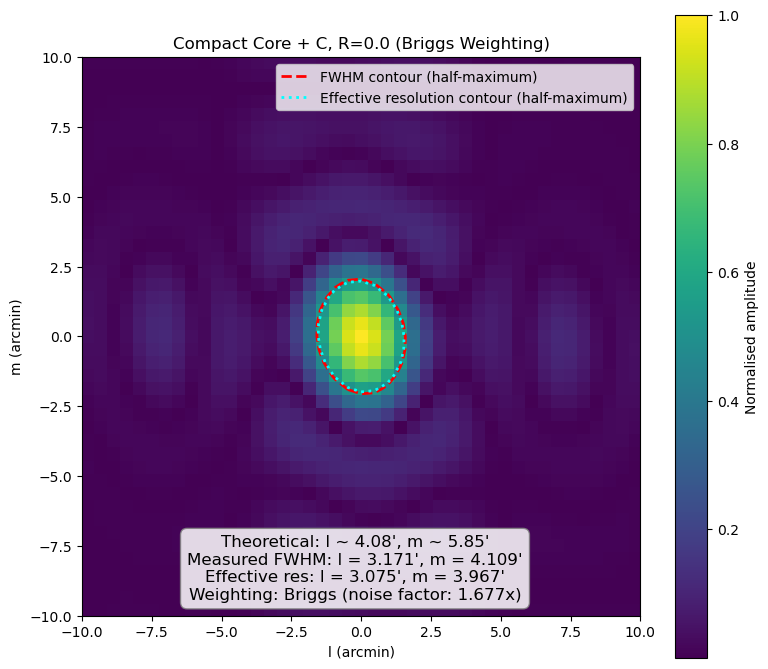

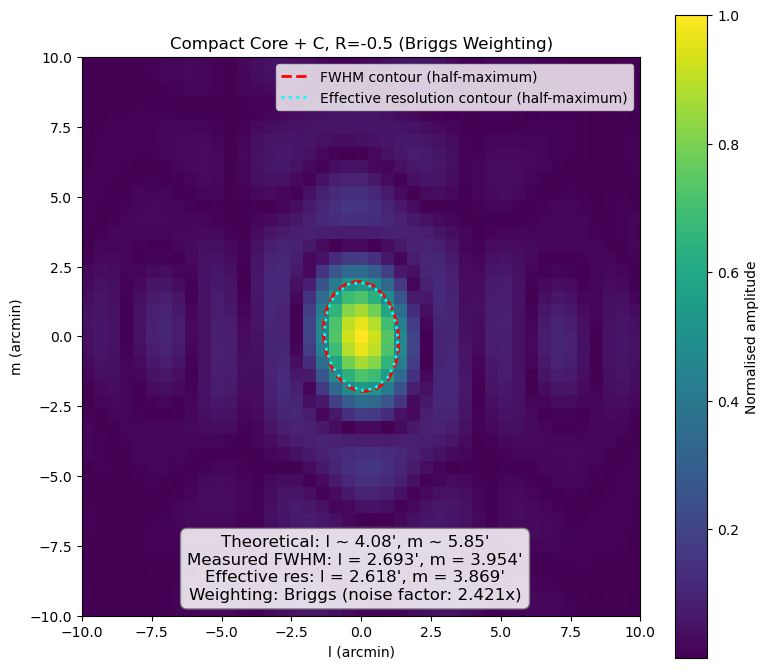

In [24]:
uvd_compact_C = setup_uvdata(compact_C, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_C, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + C: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_C, title=f"Compact Core + C, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + D

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 16 robust values in 14 bisections, total iterations: 14


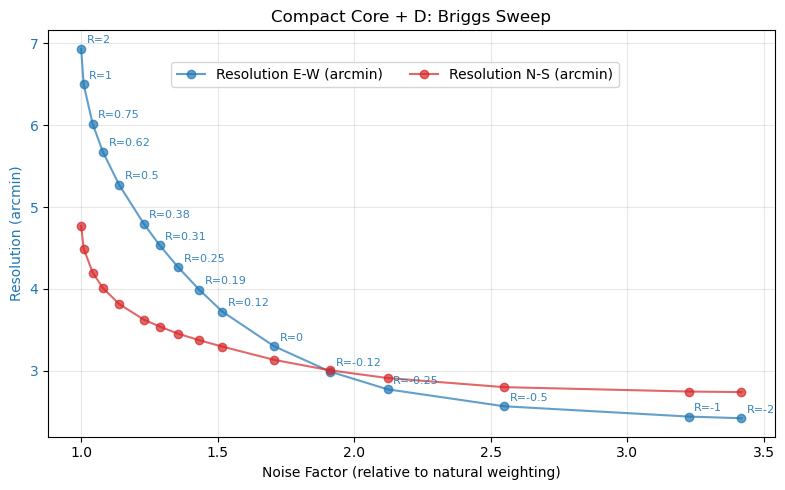

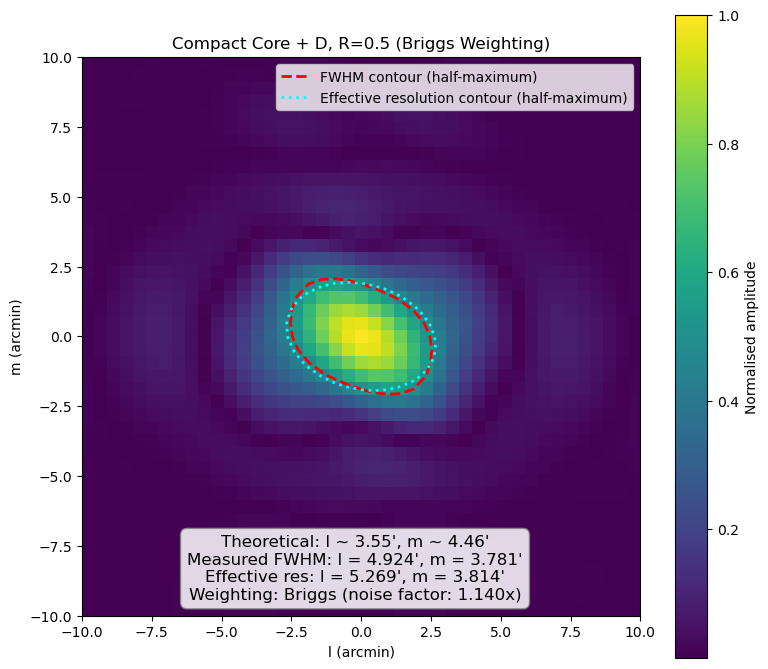

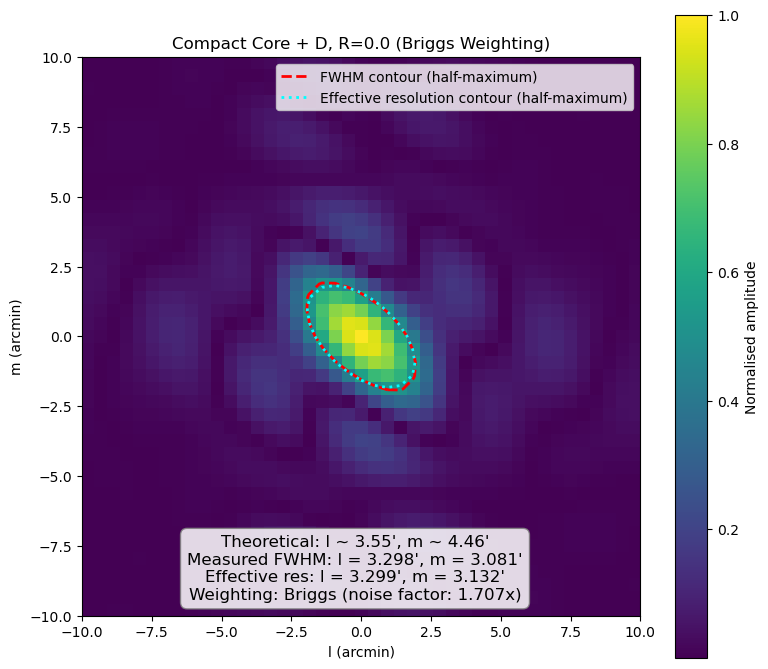

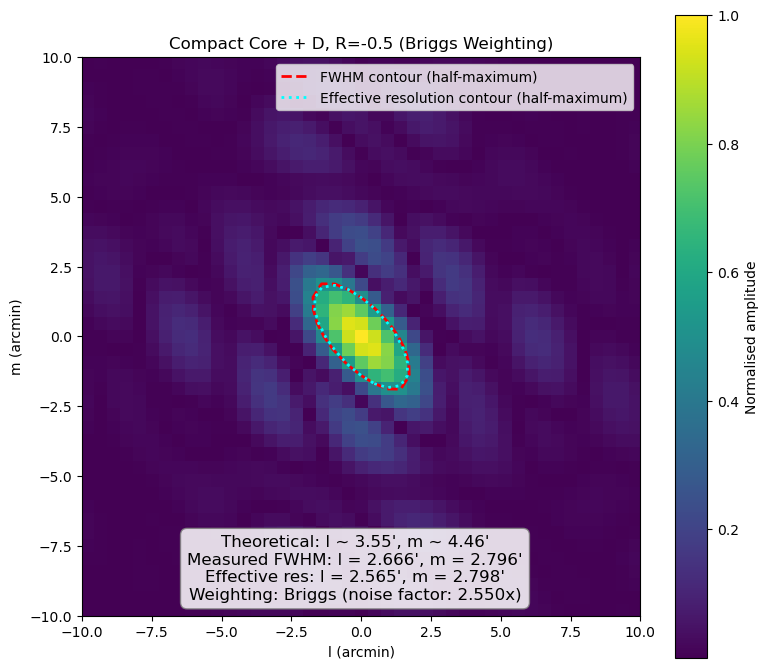

In [25]:
uvd_compact_D = setup_uvdata(compact_D, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_D, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + D: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_D, title=f"Compact Core + D, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + E

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 26 robust values in 24 bisections, total iterations: 24


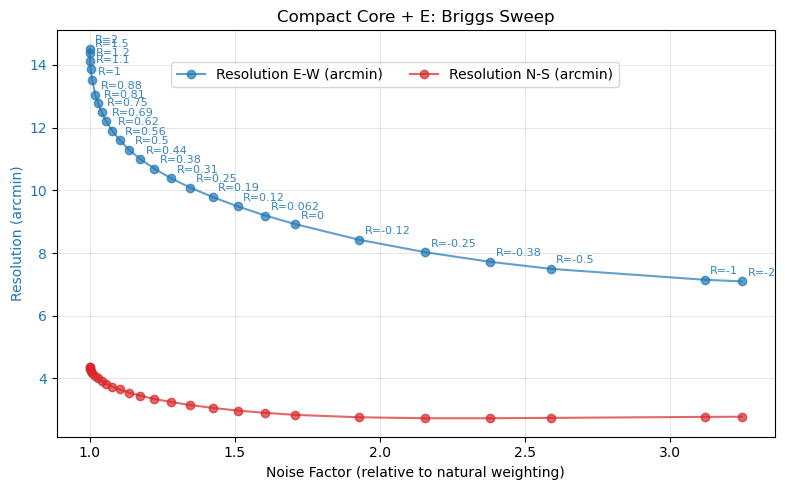

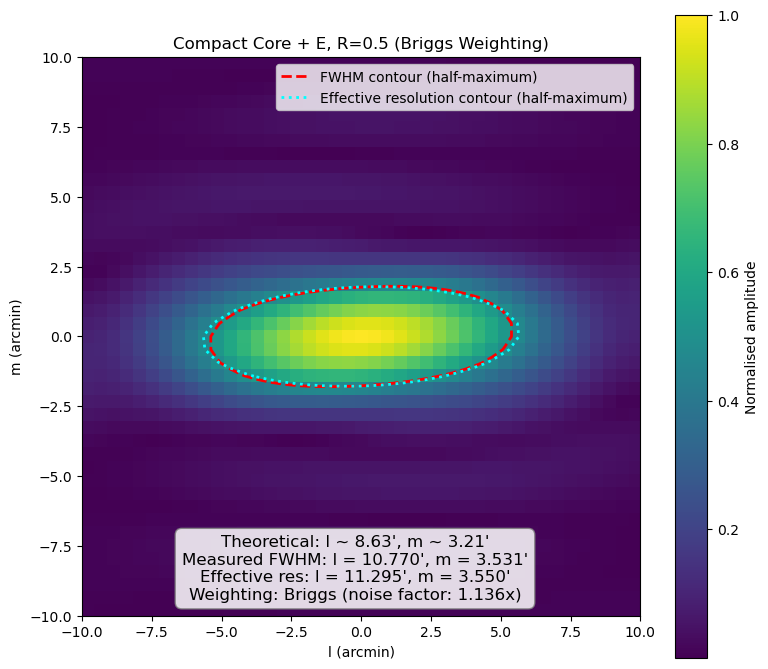

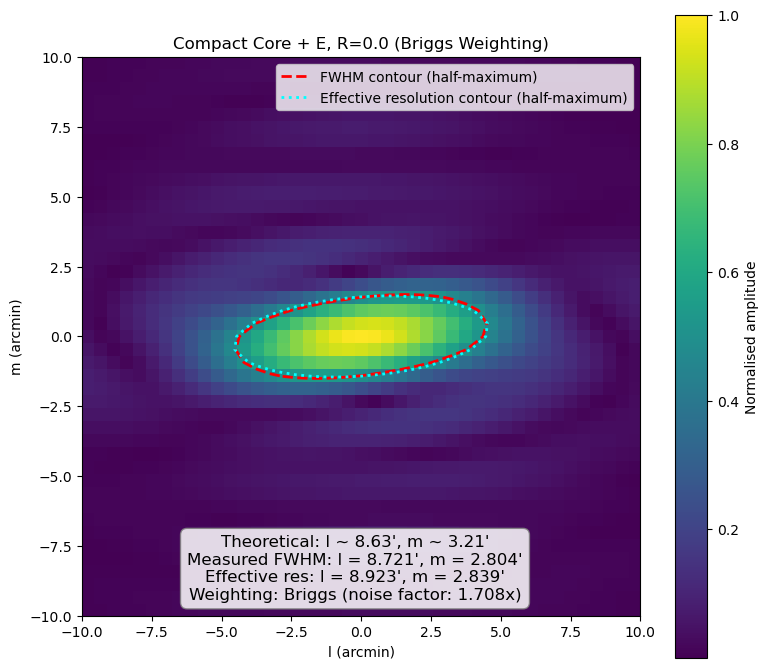

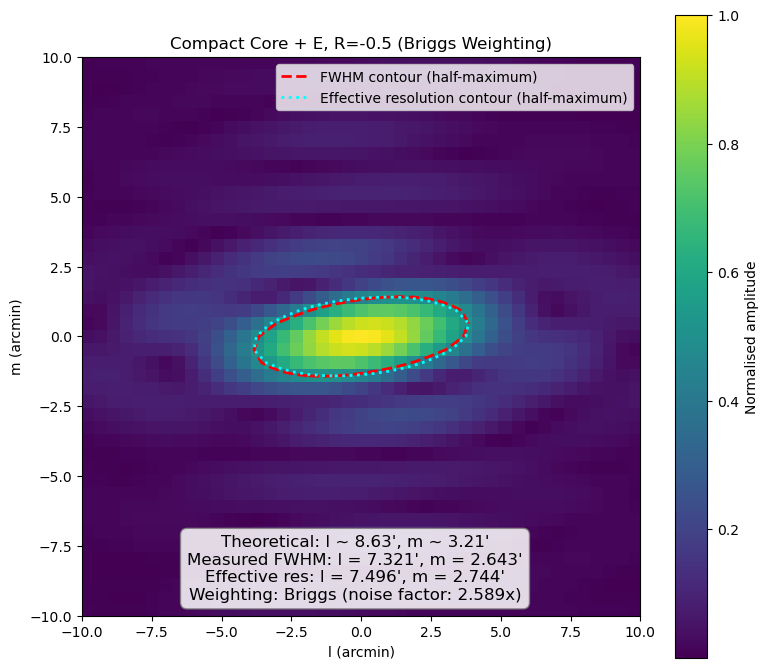

In [ ]:
uvd_compact_E = setup_uvdata(compact_E, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_E, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + E: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_E, title=f"Compact Core + E, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + F

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 29 robust values in 27 bisections, total iterations: 27


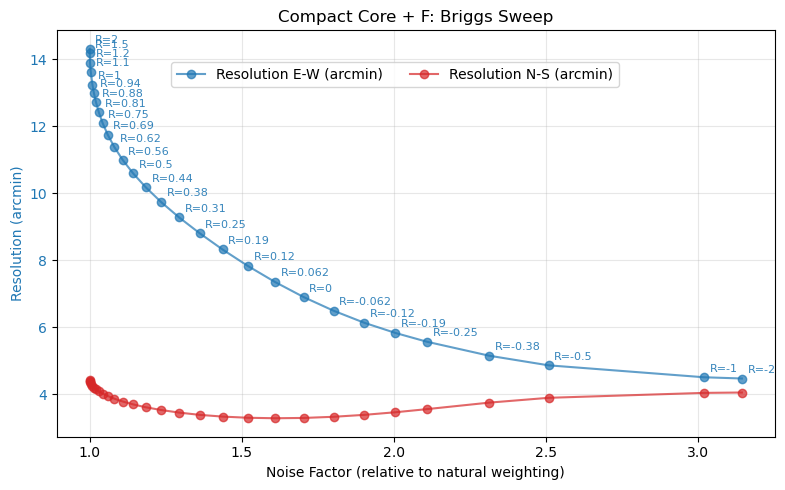

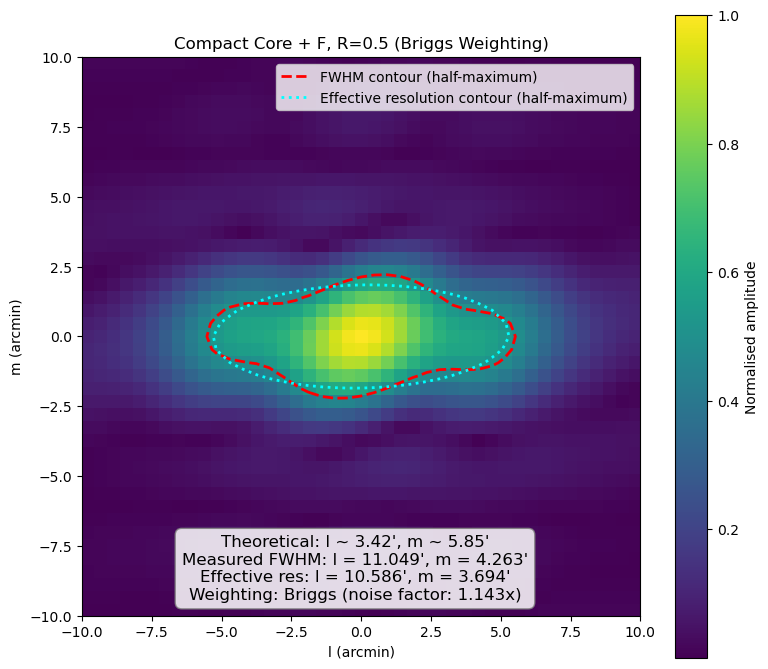

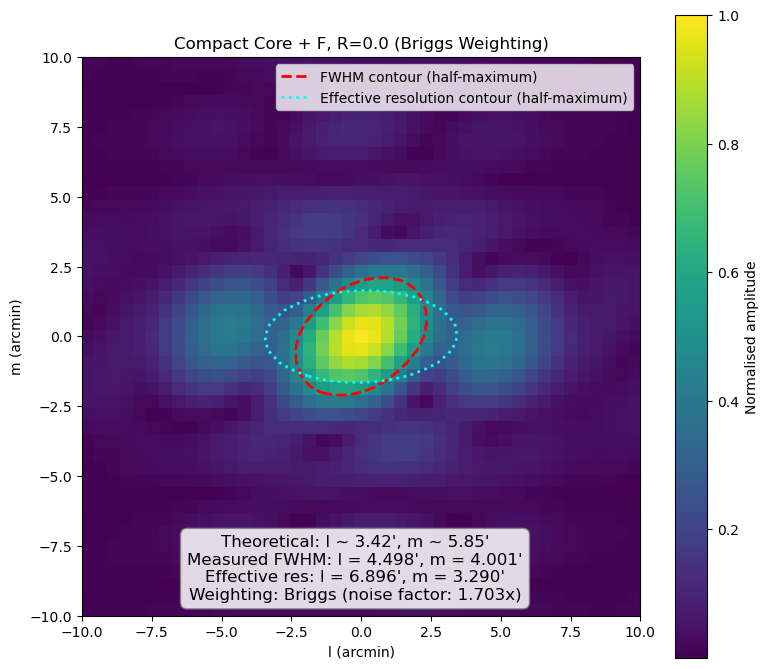

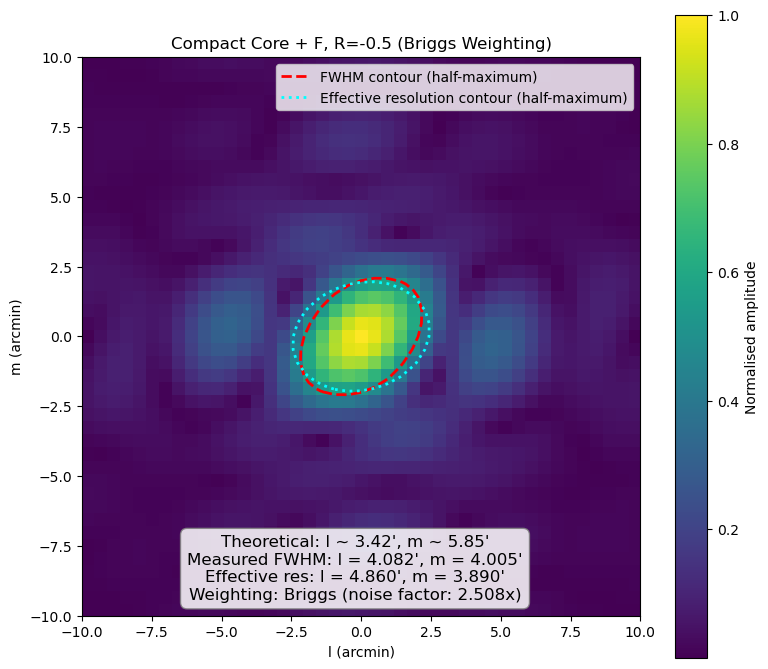

In [ ]:
uvd_compact_F = setup_uvdata(compact_F, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_F, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + F: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_F, title=f"Compact Core + F, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)

## Compact + G

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


Sampled 31 robust values in 29 bisections, total iterations: 29


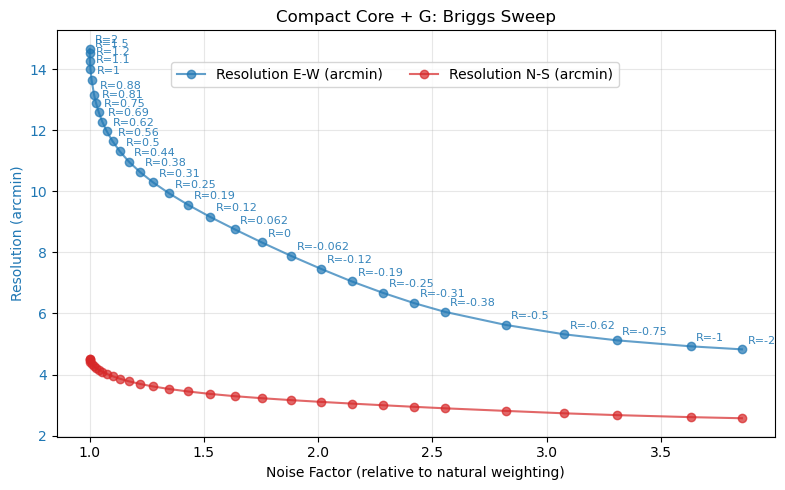

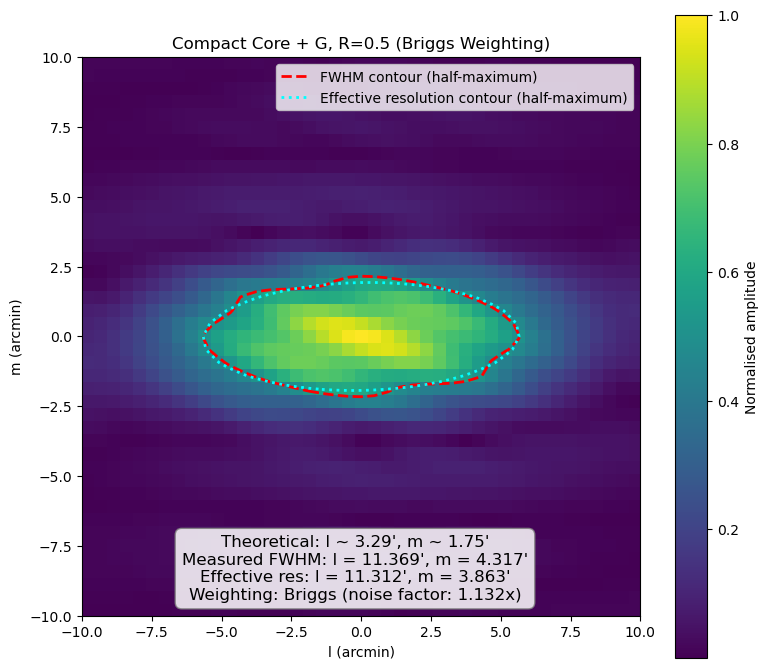

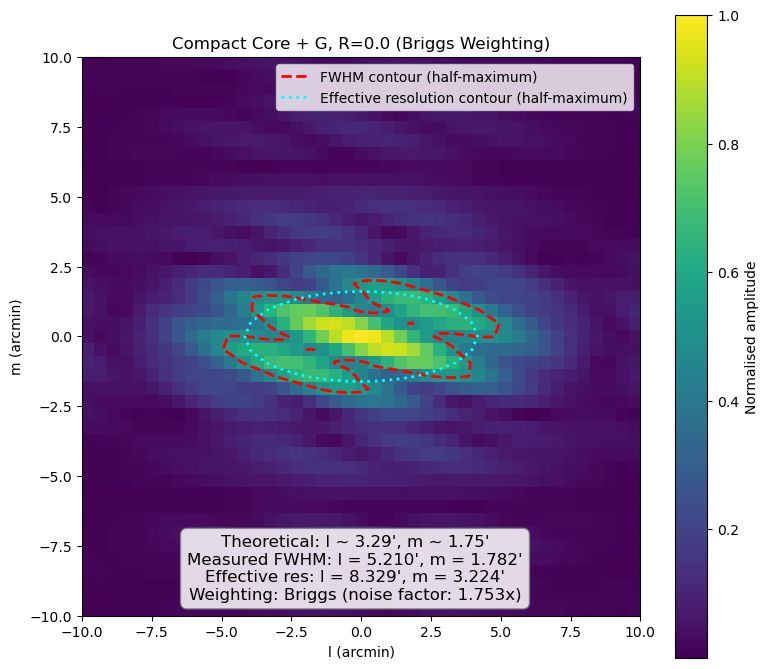

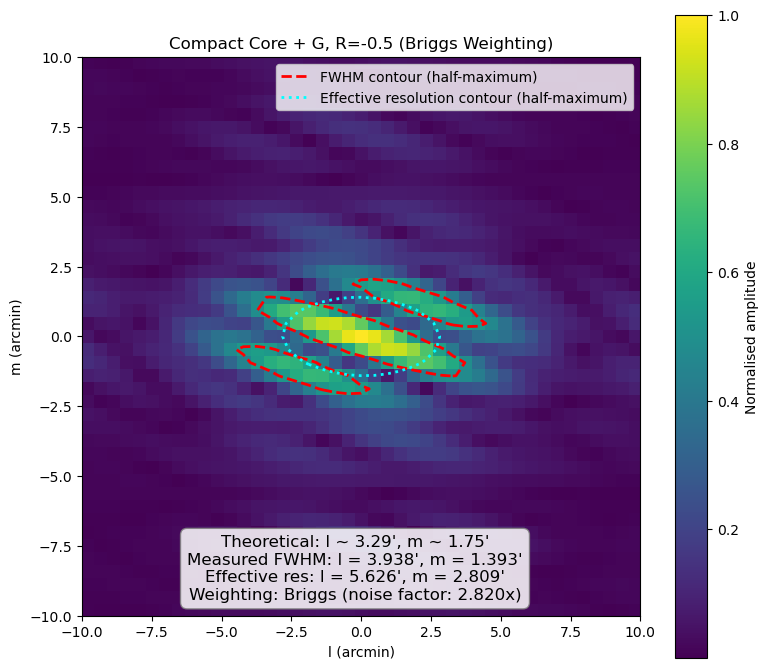

In [ ]:
uvd_compact_G = setup_uvdata(compact_G, drao_loc, freq_hz=FREQ_HZ)

r_arr, nf_arr, eff_l_arr, eff_m_arr = adaptive_briggs_sweep(
    uvd_compact_G, tol=0.5, npix=256, image_extent_deg=1,
)

plot_briggs_values("Compact Core + G: Briggs Sweep", r_arr, nf_arr, eff_l_arr, eff_m_arr)

for R in [0.5, 0.0, -0.5]:
    _ = compute_dirty_beam(uvd_compact_G, title=f"Compact Core + G, R={R}",
                    npix=npix, freq_hz=FREQ_HZ, image_extent_deg=1, robust = R, weighting="briggs", zoom_extent=10)